In [56]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import  make_blobs, make_circles
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [57]:
def initialisation2 (dimensions):
    parametres = {}
    C=len(dimensions)
    for c in range(1, C):
        parametres['W' + str(c)] = np.random.randn(dimensions[c], dimensions[c -1])
        parametres['b' + str(c)] = np.random.randn(dimensions[c], 1)
    return parametres

In [58]:
def forward_propagation2(X, parametres):
  activations = {'A0' : X}
  C = len(parametres) // 2

  for c in range (1, C + 1) :
      Z = parametres['W' + str(c)].dot(activations['A' + str(c - 1)]) + parametres['b'+ str(c)]
      if c == C: 
          activations['A' + str(c)] = Z
      else :
          activations['A' + str(c)] = 1 / (1 + np.exp(-Z))
    
  return activations

    
    

In [59]:
def mse(y, A):

    epsilon = 1e-15
    A = np.clip(A, epsilon, 1 - epsilon)

    m = y.shape[1]

    loss = 1 / m * np.sum((A - y) ** 2)

    return loss

In [60]:
def back_propagation2 (X, y, parametres , activations): 
    m = y.shape[1]
    C = len(parametres) // 2
 
    dZ = activations['A' + str(C)] - y
    gradients = {}
    
    for c in reversed(range(1, C + 1)):
        gradients['dW'+ str(c)] = 1 / m * np.dot(dZ, activations['A' + str(c - 1)].T)
        gradients['db'+ str(c)] = 1 / m * np.sum(dZ, axis=1, keepdims = True)
        if c > 1 : 
          dZ = np.dot(parametres['W' + str(c)].T, dZ) * activations['A' + str(c-1)] * (1 - activations["A" + str(c-1)])
    return gradients
    

In [61]:
def update2 (parametres , gradients, learning_rate):
    C = len(parametres) // 2
    

    for c in range (1, C + 1): 
        parametres ['W' + str(c)] = parametres['W' + str(c)] - learning_rate * gradients['dW' + str(c)]
        parametres ['b' + str(c)] = parametres['b' + str(c)] - learning_rate * gradients['db' + str(c)]
        

    return parametres

    

In [62]:
def predict2(X, parametres):
     activations = forward_propagation2(X, parametres)
     C = len(parametres)//2
     return activations['A' + str(C)]

In [103]:
def artificial_neural_network(X_train, y_train, X_test, y_test,  hidden_layers = (16, 8, 4),  learning_rate = 0.01, n_iter=1000):
   np.random.seed(0)
   #initialisations
   dimensions =list(hidden_layers)
   dimensions.insert(0, X_train.shape[0])
   dimensions.append(y_train.shape[0])
   parametres =initialisation2(dimensions)
    
  
 
   train_loss = []
   train_mse = []
   test_loss = []
   test_mse = []
   train_r2 = []
   test_r2 = []
   y_train_max = y_train.max()
   y_train_min = y_train.min()
   
   for i in range (n_iter): 
      #train
      activations = forward_propagation2(X_train, parametres)
      gradients = back_propagation2(X_train, y_train, parametres, activations)
      parametres = update2 (parametres , gradients, learning_rate)
      if i%10 == 0 : 
          C = len(parametres)//2
          train_loss.append(mse(y_train, activations['A' + str(C)]))
          y_pred = predict2 (X_train, parametres)
          train_mse.append(mean_squared_error(y_train.flatten(), y_pred.flatten()))
          train_r2.append(r2_score(y_train.flatten(), y_pred.flatten()))


       #Test
          activations = forward_propagation2(X_test, parametres)
          test_loss.append(mse(y_test, activations['A' + str(C)]))
          y_pred = predict2 (X_test, parametres)
          test_mse.append(mean_squared_error(y_test.flatten(), y_pred.flatten()))
          test_r2.append(r2_score(y_test.flatten(), y_pred.flatten()))
    
   
  
       
                   

   plt.figure(figsize=(12, 8))
   plt.subplot(1, 3, 1)
   plt.plot(train_loss, label="train_loss")
   plt.plot(test_loss, label="test_loss")
   plt.legend()
   plt.savefig('loss.png')
   plt.subplot(1, 3, 2)
   plt.plot(train_mse, label="train_mse")  
   plt.plot(test_mse, label="test_mse")
   plt.legend()
   plt.savefig('mse.png')
   plt.subplot(1, 3, 3)
   plt.plot(train_r2, label="train_r2")  
   plt.plot(test_r2, label="test_r2")  
   plt.legend()
   plt.savefig('r2.png')
   
   return parametres
    

In [64]:
df2 = pd.read_csv("student_productivity.csv")
df2.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [65]:
df2 = df2.drop('student_id', axis=1)
df2.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [66]:
#Analyse et exploration des données(EDA)
df2.shape

(5000, 20)

In [67]:
df2.dtypes.value_counts()

float64    11
int64       6
object      3
Name: count, dtype: int64

In [68]:
df2.isna().sum() / df2.shape[0]

age                     0.0
gender                  0.0
academic_level          0.0
study_hours             0.0
self_study_hours        0.0
online_classes_hours    0.0
social_media_hours      0.0
gaming_hours            0.0
sleep_hours             0.0
screen_time_hours       0.0
exercise_minutes        0.0
caffeine_intake_mg      0.0
part_time_job           0.0
upcoming_deadline       0.0
internet_quality        0.0
mental_health_score     0.0
focus_index             0.0
burnout_level           0.0
productivity_score      0.0
exam_score              0.0
dtype: float64

In [69]:
#Visalisation de la target 
df2['exam_score'].max()

64.09

In [70]:
df2['gender'].value_counts(normalize=True)


gender
Male      0.3438
Other     0.3302
Female    0.3260
Name: proportion, dtype: float64

In [71]:
df2['exam_score'].mean()

np.float64(18.803752000000003)

In [72]:
df2[df2['exam_score'] > 30].value_counts(normalize=True).shape[0]

950

In [73]:
df2[df2['exam_score'] > 50].groupby('gender').size()

gender
Female    10
Male      15
Other     10
dtype: int64

In [74]:
df2[df2['exam_score'] < 10].groupby('gender').size()

gender
Female    425
Male      452
Other     448
dtype: int64

In [75]:
df2['internet_quality'].value_counts(normalize=True)

internet_quality
Good       0.3444
Poor       0.3280
Average    0.3276
Name: proportion, dtype: float64

In [76]:
df2['part_time_job'].groupby(df2['gender']).value_counts()

gender  part_time_job
Female  0                827
        1                803
Male    0                871
        1                848
Other   1                840
        0                811
Name: count, dtype: int64

In [77]:
df2['academic_level'].value_counts(normalize=True)

academic_level
Postgraduate     0.3374
High School      0.3344
Undergraduate    0.3282
Name: proportion, dtype: float64

In [78]:
df2[df2['study_hours'] > 10 ].groupby(df2['gender']).size()

gender
Female    3
Male      4
Other     1
dtype: int64

In [79]:
df2[df2['study_hours'] < 1 ].groupby(df2['gender']).size()

gender
Female    44
Male      43
Other     43
dtype: int64

In [80]:
df2[df2['sleep_hours'] > 9 ].groupby(df2['gender']).size()

gender
Female    80
Male      57
Other     81
dtype: int64

In [81]:
df2[df2['sleep_hours'] < 5 ].groupby(df2['gender']).size()

gender
Female    67
Male      74
Other     61
dtype: int64

In [82]:
df2[df2['sleep_hours'] < 4].groupby(df2['gender']).size()

Series([], dtype: int64)

In [83]:
#Preprocessing
data = df2.copy()
    


In [84]:
data.head()

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [85]:
data['exam_score'].min()

1.0

In [86]:
trainset , testset = train_test_split(data, test_size = 0.2)

In [87]:
print(trainset.shape)

(4000, 20)


In [88]:
print(testset.shape)

(1000, 20)


In [89]:
for i in  data.select_dtypes('object') :
        print(i , data[i].unique())

gender ['Other' 'Male' 'Female']
academic_level ['High School' 'Undergraduate' 'Postgraduate']
internet_quality ['Good' 'Poor' 'Average']


In [90]:
def encodage(data) :
    cols = ['gender', 'academic_level', 'internet_quality']
    model = OrdinalEncoder ()
    data[cols] = model.fit_transform(data[cols])

    return data

In [91]:
#normalisation
def normalisation (data):
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    return data

In [92]:
def preprocessing(data):
  
    data = encodage(data)
    X = data.drop('exam_score', axis=1)
    y = data['exam_score']
    X = normalisation(X)
    y_min = y.min()
    y_max = y.max()
    y_norm = (y - y_min) / (y_max - y_min)

   
    y_norm = y_norm.to_numpy()

    

    

    return X, y_norm




In [93]:
X_train, y_train = preprocessing(trainset)

In [94]:
X_train.shape

(4000, 19)

In [95]:
y_train.shape

(4000,)

In [96]:
X_test, y_test = preprocessing(testset)

In [97]:
X_test.shape

(1000, 19)

In [98]:
y_test.shape

(1000,)

In [99]:
#Tranformation 
X_train = X_train.T
X_test = X_test.T
y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)

In [100]:
X_train.shape

(19, 4000)

In [101]:
y_test.shape[0]

1

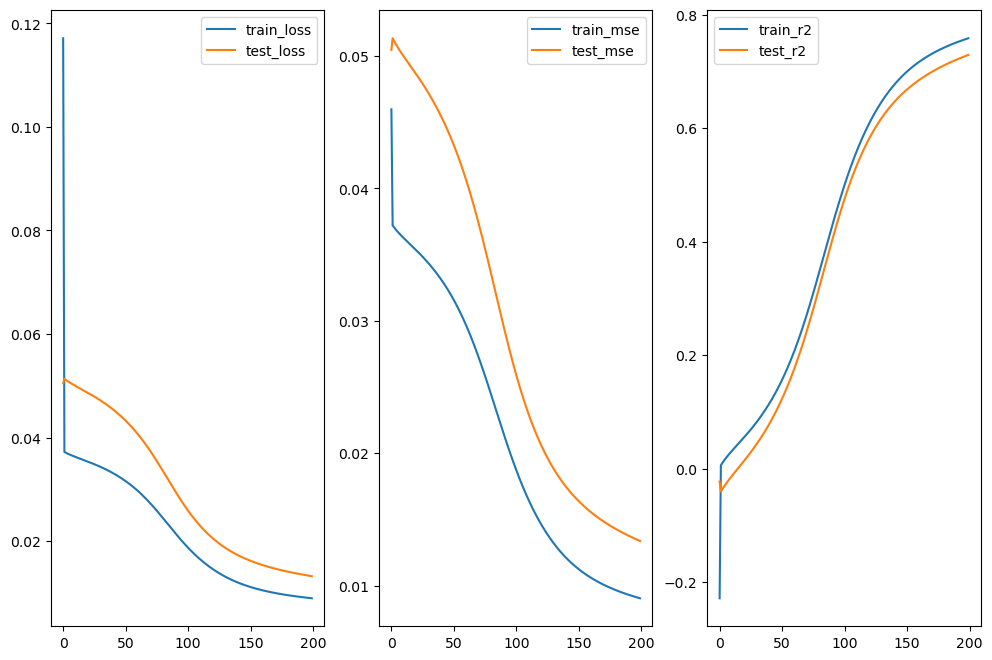

In [104]:
parametres = artificial_neural_network(X_train, y_train, X_test, y_test, hidden_layers = (8, 2), learning_rate = 0.8, n_iter=2000)